In [2]:
import os
import random
import shutil
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

#config

BASE_DIR = Path.home() / "projeto_tafresco"
RAW_DIR = BASE_DIR / "data" / "raw" / "train"
PROCESSED_DIR = BASE_DIR / "data" / "processed"
CLASSES = ["Not_Fresh", "Fresh", "Highly_Fresh"]
LIMIT_PER_CLASS = 1760 #quantidade da classe minoritária
SPLITS = {"train": 0.70, "val": 0.15, "test": 0.15}

def setup_folders():
    """estrutura de pastas"""
    for split in SPLITS.keys():
        for cls in CLASSES:
            (PROCESSED_DIR / split / cls).mkdir(parents=True, exist_ok=True)

def copy_worker(task):
    """copia paralelamente(auxiliar)"""
    src, dst = task
    shutil.copy2(src, dst)

def balance_and_split():
    """FUNÇÃO PRINCIPAL"""
    all_copy_tasks = []

    for cls in CLASSES:
        cls_path = RAW_DIR / cls
        # filtra imagens válidas
        images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        #undersampling
        random.seed(42)
        selected_images = random.sample(images, min(len(images), LIMIT_PER_CLASS))
        random.shuffle(selected_images)

        #indices do split
        total = len(selected_images)
        idx_train = int(total * SPLITS["train"])
        idx_val = idx_train + int(total * SPLITS["val"])

        split_map = {
            "train": selected_images[:idx_train],
            "val": selected_images[idx_train:idx_val],
            "test": selected_images[idx_val:]
        }

        #preparação p/ threadpool
        for split, imgs in split_map.items():
            for img in imgs:
                src = cls_path / img
                dst = PROCESSED_DIR / split / cls / img
                all_copy_tasks.append((src, dst))

        print(f"Classe: {cls}: {len(selected_images)} imagens selecionadas o pipeline. "
              f"→ train = {idx_train}, val = {idx_val - idx_train}, test = {total - idx_val}")

        #execução paralela
        print(f" Iniciando cópia de {len(all_copy_tasks)} ficheiros em paralelo...")
        with ThreadPoolExecutor(max_workers=os.cpu_count()) as executor:
            list(executor.map(copy_worker, all_copy_tasks))

if __name__ == "__main__":
    setup_folders()
    balance_and_split()
    print(f" DATASET MVP PRONTO EM: {PROCESSED_DIR}")


Classe: Not_Fresh: 1760 imagens selecionadas o pipeline. → train = 1232, val = 264, test = 264
 Iniciando cópia de 1760 ficheiros em paralelo...
Classe: Fresh: 1760 imagens selecionadas o pipeline. → train = 1232, val = 264, test = 264
 Iniciando cópia de 3520 ficheiros em paralelo...
Classe: Highly_Fresh: 1760 imagens selecionadas o pipeline. → train = 1232, val = 264, test = 264
 Iniciando cópia de 5280 ficheiros em paralelo...
 DATASET MVP PRONTO EM: /home/tafresco/projeto_tafresco/data/processed


In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
import matplotlib.pyplot as plt

# 1. Configurações Globais
BATCH_SIZE = 32
IMG_SIZE = (224, 224) # Tamanho nativo ideal para a MobileNetV2
NUM_CLASSES = 3
PATH_MVP = "../data/processed"

# 2. Lazy Loading: Construindo o Pipeline de Dados
print("Carregando datasets...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    f"{PATH_MVP}/train", shuffle=True, image_size=IMG_SIZE, batch_size=BATCH_SIZE)

val_ds = tf.keras.utils.image_dataset_from_directory(
    f"{PATH_MVP}/val", shuffle=False, image_size=IMG_SIZE, batch_size=BATCH_SIZE)

class_names = train_ds.class_names
print(f"Classes identificadas: {class_names}")

# 3. Data Augmentation (Simulando a Feira)
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.15), # Rotação leve, pois o olho não tem um eixo fixo
    layers.RandomBrightness(factor=0.2), # Fundamental para lidar com sombras e flash
    layers.RandomFlip("horizontal_and_vertical"),
], name="camada_aumento_dados")

# 4. Otimização de Performance (Uso de RAM e GPU)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# 5. Construindo a Arquitetura (Transfer Learning)
print("Baixando pesos da MobileNetV2...")
base_model = MobileNetV2(input_shape=IMG_SIZE + (3,), 
                         include_top=False, 
                         weights='imagenet') # Aproveita o que o Google já treinou

# Congelamos a base para o primeiro treino
base_model.trainable = False 

# Montando a Cabeça de Classificação do TáFresco
inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
# A MobileNetV2 espera pixels entre [-1, 1]
x = tf.keras.applications.mobilenet_v2.preprocess_input(x) 
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x) # Previne overfitting
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x) # 3 classes de frescor

model = models.Model(inputs, outputs)

# 6. Compilando o Modelo
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

ModuleNotFoundError: No module named 'tensorflow'

🚀 Iniciando treinamento para até 25 épocas...
Epoch 1/25


2026-04-24 17:01:55.465961: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2026-04-24 17:01:55.853827: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: Permission denied


  4/116 [>.............................] - ETA: 2s - loss: 1.2828 - accuracy: 0.4688  

2026-04-24 17:01:56.834378: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f3dc809dd10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-24 17:01:56.834402: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 4070 Ti, Compute Capability 8.9
2026-04-24 17:01:56.843944: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777060916.908184   66328 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


116/116 [==============================] - ETA: 0s - loss: 0.9893 - accuracy: 0.5530
Epoch 1: val_accuracy improved from -inf to 0.62500, saving model to ../models/tafresco_mvp_v1.keras
116/116 [==============================] - 7s 33ms/step - loss: 0.9893 - accuracy: 0.5530 - val_loss: 0.7732 - val_accuracy: 0.6250
Epoch 2/25
115/116 [============================>.] - ETA: 0s - loss: 0.8001 - accuracy: 0.6438
Epoch 2: val_accuracy improved from 0.62500 to 0.66919, saving model to ../models/tafresco_mvp_v1.keras
116/116 [==============================] - 3s 22ms/step - loss: 0.8001 - accuracy: 0.6437 - val_loss: 0.7247 - val_accuracy: 0.6692
Epoch 3/25
113/116 [============================>.] - ETA: 0s - loss: 0.7519 - accuracy: 0.6690
Epoch 3: val_accuracy improved from 0.66919 to 0.67045, saving model to ../models/tafresco_mvp_v1.keras
116/116 [==============================] - 3s 22ms/step - loss: 0.7523 - accuracy: 0.6688 - val_loss: 0.6914 - val_accuracy: 0.6705
Epoch 4/25
115/116

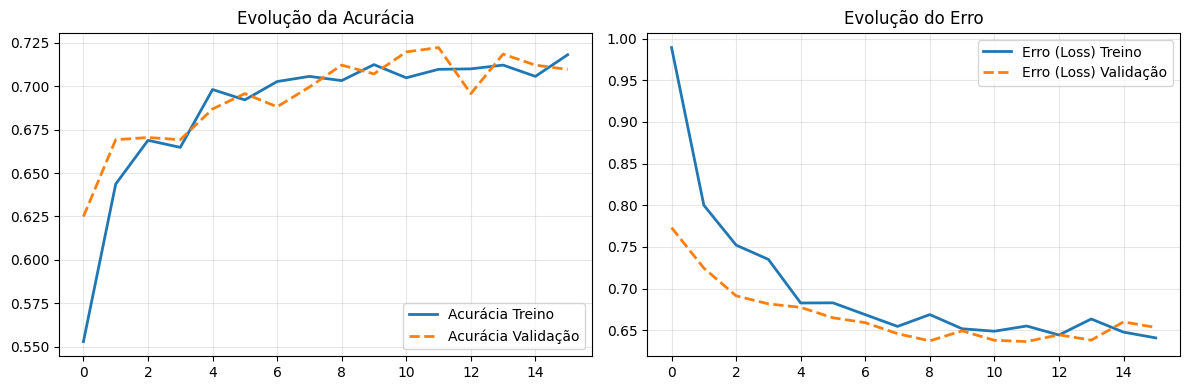

✅ Treinamento finalizado. Melhor modelo salvo em: ../models/tafresco_mvp_v1.keras


In [ ]:
import os

# 1. Parâmetros de Treinamento
# 25 épocas é muito seguro para Transfer Learning de topo
EPOCHS = 25 

# Garante que a pasta existe para salvar o modelo
os.makedirs("../models", exist_ok=True)
caminho_modelo = "../models/tafresco_mvp_v1.keras" # Formato moderno recomendado pelo TF 2.15

# 2. Configurando os Callbacks (Os "Fiscais" do Treinamento)
callbacks = [
    # Fiscal 1: EarlyStopping (Evita Overfitting)
    # Se a perda na validação (val_loss) não cair por 4 épocas seguidas, ele aborta.
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=4, 
        restore_best_weights=True, # Garante que você fique com a melhor versão, não a última
        verbose=1
    ),
    
    # Fiscal 2: ModelCheckpoint (Salva o progresso)
    # Salva no HD apenas quando atinge um novo recorde de acurácia na validação
    tf.keras.callbacks.ModelCheckpoint(
        filepath=caminho_modelo,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# 3. O Treinamento (Aqueçam os motores da RTX 4070 Ti!)
print(f"🚀 Iniciando treinamento para até {EPOCHS} épocas...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

# 4. Avaliação Visual (Gráficos)
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Acurácia Treino', linewidth=2)
plt.plot(val_acc, label='Acurácia Validação', linewidth=2, linestyle='--')
plt.title('Evolução da Acurácia')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(loss, label='Erro (Loss) Treino', linewidth=2)
plt.plot(val_loss, label='Erro (Loss) Validação', linewidth=2, linestyle='--')
plt.title('Evolução do Erro')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Treinamento finalizado. Melhor modelo salvo em: {caminho_modelo}")

2026-05-05 12:33:43.867899: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-05 12:33:44.153254: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-05 12:33:44.153281: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-05 12:33:44.196487: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-05 12:33:44.288309: I tensorflow/core/platform/cpu_feature_guar

1. Recriando o pipeline de validação...
Found 792 files belonging to 3 classes.


2026-05-05 12:33:46.163748: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-05 12:33:46.310647: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-05 12:33:46.310677: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-05 12:33:46.313714: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-05 12:33:46.313745: I external/local_xla/xla/stream_executor


2. Carregando o cérebro da IA salvo no disco...

3. Coletando previsões do modelo no dataset de validação...


2026-05-05 12:33:48.606821: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2026-05-05 12:33:48.848941: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: Permission denied



4. Gerando Matriz de Confusão...


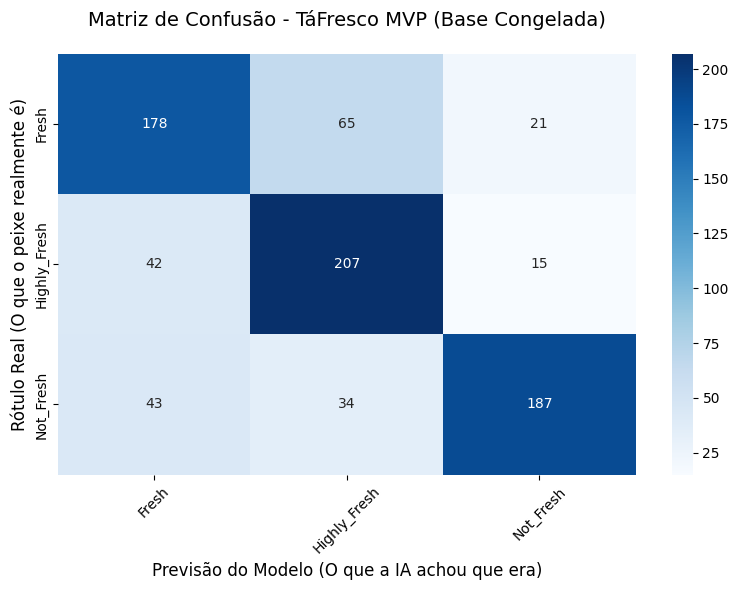


📊 Relatório de Classificação Detalhado:
              precision    recall  f1-score   support

       Fresh       0.68      0.67      0.68       264
Highly_Fresh       0.68      0.78      0.73       264
   Not_Fresh       0.84      0.71      0.77       264

    accuracy                           0.72       792
   macro avg       0.73      0.72      0.72       792
weighted avg       0.73      0.72      0.72       792



In [2]:
import tensorflow as tf
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

print("1. Recriando o pipeline de validação...")
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
PATH_MVP = "../data/processed"

# Recria apenas o dataset de validação
val_ds = tf.keras.utils.image_dataset_from_directory(
    f"{PATH_MVP}/val", 
    shuffle=False, 
    image_size=IMG_SIZE, 
    batch_size=BATCH_SIZE
)
val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

print("\n2. Carregando o cérebro da IA salvo no disco...")
# Carrega o modelo que o nosso callback salvou
caminho_modelo = "../models/tafresco_mvp_v1.keras"
model = tf.keras.models.load_model(caminho_modelo)

print("\n3. Coletando previsões do modelo no dataset de validação...")
y_true = []
y_pred_probs = []

for images, labels in val_ds:
    y_true.extend(labels.numpy())
    preds = model.predict(images, verbose=0)
    y_pred_probs.extend(preds)

y_true = np.array(y_true)
y_pred = np.argmax(y_pred_probs, axis=1) 

# Os nomes das classes definidos manualmente como corrigimos
class_names = ['Fresh', 'Highly_Fresh', 'Not_Fresh']

print("\n4. Gerando Matriz de Confusão...")
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)

plt.title('Matriz de Confusão - TáFresco MVP (Base Congelada)', pad=20, fontsize=14)
plt.ylabel('Rótulo Real (O que o peixe realmente é)', fontsize=12)
plt.xlabel('Previsão do Modelo (O que a IA achou que era)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n📊 Relatório de Classificação Detalhado:")
print(classification_report(y_true, y_pred, target_names=class_names))